In [16]:
# Import the NumPy library as 'np' to provide support for high-performance multi-dimensional arrays and mathematical operations, which is crucial for handling input data arrays and mathematical transformations in neural networks.
import numpy as np
# Import the Pandas library as 'pd' to enable powerful data manipulation, structured DataFrame creation, and CSV file reading capabilities, which are essential for loading and preprocessing the tabular dataset.
import pandas as pd

In [17]:
# Read the Boston Housing dataset from the '1_linear_boston.csv' file into a Pandas DataFrame named 'df'. This is important because it loads the raw tabular data (features and target variable) into memory, serving as the foundation of our entire data pipeline.
df = pd.read_csv("1_linear_boston.csv")

In [18]:
# Extract all rows and all columns except the last one to define the feature matrix 'x'. This is important because it isolates the independent variables (features) used to predict the house prices, excluding the target column.
x=df.iloc[:,0:-1]
# Select the 'MEDV' (Median Value of owner-occupied homes in $1000s) column as the target variable vector 'y'. This is important because it defines the continuous labels that the Deep Neural Network will learn to predict.
y=df['MEDV']

In [19]:
# Import 'train_test_split' from scikit-learn's model_selection module to enable random splitting of the dataset. This is important to ensure a standardized method for partitioning the data into training and testing subsets.
from sklearn.model_selection import train_test_split
# Split the features 'x' and target 'y' into training (80%) and testing (20%) datasets, setting random_state=42 for reproducibility. This is important to evaluate the model's generalization performance on unseen test data and prevent overfitting.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Import 'RobustScaler' from scikit-learn's preprocessing module. This is important because scaling features is essential for stable gradient descent in neural networks, and RobustScaler uses statistics that are robust to outliers.
from sklearn.preprocessing import RobustScaler
# Instantiate the RobustScaler, which scales features using statistics (median and IQR) that are robust to outliers. This is important because the Boston housing dataset contains significant outliers, and standard scaling might be distorted by them.
scaler = RobustScaler() # robust to outliers due to median
# Fit the scaler on the training features to compute medians and IQRs, then transform the training features. This is important because it learns the data distribution of the training set and normalizes it to prevent feature scaling imbalance.
x_train = scaler.fit_transform(x_train)
# Transform the test features using the medians and IQRs learned from the training set. This is important to ensure the test data is scaled in the exact same way as training data without leaking test set statistics into the training phase.
x_test = scaler.transform(x_test)

In [ ]:
# Import 'Sequential' from Keras models to allow building the neural network as a linear stack of layers. This is important as it provides a simple, structured API for constructing feedforward deep learning models layer by layer.
from tensorflow.keras.models import Sequential
# Import key layers: 'Dense' for fully connected layers, 'Dropout' for regularization, 'Input' to define the shape of incoming data, and 'BatchNormalization' to normalize intermediate activations. These are important for constructing a robust, high-performance deep neural network architecture.
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization

# Instantiate the Sequential model containing the specified neural network layers. This is important because it acts as the primary container defining the topology and forward pass execution of our model.
model = Sequential([
    # Define an Input layer specifying the input shape of (13,), matching the 13 features of the Boston dataset. This is important to establish the initial tensor dimensions and allow dynamic graph initialization in TensorFlow.
    Input(shape=(13,)),
    
    # Add a BatchNormalization layer to normalize activations across mini-batches. This is important because it stabilizes training, reduces internal covariate shift, and allows higher learning rates with faster convergence.
    BatchNormalization(),
    # Add a fully-connected Dense layer with 64 units and a Rectified Linear Unit (ReLU) activation function. This is important because ReLU introduces non-linearity, mitigates the vanishing gradient problem, and is highly computationally efficient.
    Dense(64, activation='relu'), # avoids vanishing gradient problem, simple and fast
    # Add a Dropout layer with a rate of 0.2, randomly setting 20% of activation outputs to 0 during each training step. This is important because it acts as a regularizer, preventing co-adaptation of features and reducing the risk of overfitting.
    Dropout(0.2),

    # Add a second fully-connected Dense layer with 32 units and ReLU activation. This is important because it allows the model to learn more complex, abstract representations and combinations of the input features at a deeper level.
    Dense(32, activation='relu'),
    # Add the final Dense layer with a single output unit and no activation function (equivalent to linear activation). This is important because this is a regression task, requiring a continuous real-valued prediction representing the house price.
    Dense(1)
])

# Print a comprehensive summary of the model architecture, listing layers, output shapes, and parameter counts. This is important to verify the network structure, check shape compatibility, and monitor the total number of trainable vs. non-trainable weights.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization_1                │ (None, 13)                  │              52 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,061 (11.96 KB)

 Trainable params: 3,035 (11.86 KB)

 Non-trainable params: 26 (104.00 B)

In [ ]:
# Import the 'EarlyStopping' callback from Keras. This is important because it monitors the validation metric during training and halts execution when performance stops improving, helping to prevent overfitting and save compute time.
from tensorflow.keras.callbacks import EarlyStopping

# Compile the Keras model with the Adam optimizer, Mean Squared Error (MSE) loss function, and Mean Absolute Error (MAE) metric. This is important because Adam dynamically adjusts learning rates, MSE heavily penalizes larger errors, and MAE gives a directly interpretable metric of error.
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # mse penalizes large errors

# Configure the EarlyStopping callback to monitor 'val_loss', wait for 7 consecutive epochs of no improvement ('patience=7'), and revert model weights to the best epoch ('restore_best_weights=True'). This is important to ensure optimal generalization and avoid saving overfitted weights.
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the model using training data ('x_train', 'y_train'), setting aside 20% of the training data for validation, running up to 200 epochs with a batch size of 16, and applying the EarlyStopping callback. This is important because it updates the weights via backpropagation and tracks convergence.
history = model.fit(x_train, y_train, validation_split=0.2, epochs=200, batch_size=16, callbacks=[early_stop])

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 606.1786 - mae: 22.6529 - val_loss: 527.3057 - val_mae: 21.3328
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 534.7689 - mae: 21.0243 - val_loss: 467.3182 - val_mae: 19.8627
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 435.8077 - mae: 18.5824 - val_loss: 372.4859 - val_mae: 17.3981
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 296.6328 - mae: 14.7818 - val_loss: 239.3931 - val_mae: 13.6036
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 147.3470 - mae: 9.4678 - val_loss: 112.8064 - val_mae: 8.5584
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 81.1470 - mae: 6.8033 - val_loss: 63.3966 - val_mae: 5.7798
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 66.1818 - mae: 6.1522 - val_loss: 49.2013 - val_mae: 4.9685
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 55.6289 - mae: 5.5852 - val_loss: 43.1962 - val_mae: 4.5916
Epoch 9/200
21/21 ━━━━━━━━━━━

In [ ]:
# Import evaluation metrics 'mean_squared_error' and 'r2_score' from scikit-learn. This is important to quantitatively measure model performance, allowing comparisons against baselines and ensuring accurate model assessment.
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Evaluate Model
# -----------------------------
# Generate model predictions for the test features 'x_test' using the trained network. This is important because it simulates real-world usage on unseen data to test the predictive power of our Deep Neural Network.
y_pred = model.predict(x_test)

# Calculate the Mean Squared Error (MSE) between the actual test labels 'y_test' and the predicted values 'y_pred'. This is important to measure the average squared difference, which acts as the quantitative cost of the model's errors.
mse = mean_squared_error(y_test, y_pred)
# Compute the Root Mean Squared Error (RMSE) by taking the square root of the MSE. This is important because it scales the error metric back to the original unit ($1000s), making the average error easily interpretable.
rmse = np.sqrt(mse)
# Calculate the R-squared (coefficient of determination) score using the test labels and predictions. This is important because it indicates the proportion of variance in the target variable that is predictable from the input features (e.g., a score of 0.80 means 80% explained variance).
r2 = r2_score(y_test, y_pred)

# Print a newline and header for the model performance section to organize the terminal output. This is important for clean and readable console logs.
print("\nModel Performance")
# Print a separator line to visually group the quantitative metrics. This is important to make the printed output visually structured and professional.
print("-------------------")
# Print the calculated Root Mean Squared Error (RMSE) of the test set predictions. This is important to show the average prediction error in the actual price units of the houses.
print("RMSE :", rmse)
# Print the calculated R-squared score. This is important to evaluate the overall goodness-of-fit and explainability of the neural network regression model on unseen test data.
print("R2 Score :", r2) # 80% of the variance in the house prices can be explained by the inputs in your model

# -----------------------------
# Sample Predictions
# -----------------------------
# Print a newline and header for the sample predictions section. This is important to visually separate the overall performance summary from the individual comparison samples.
print("\nSample Predictions")
# Print a separator line for the sample predictions table to improve visual layout. This is important to clearly format the logs.
print("-------------------")

# Iterate 5 times to compare individual actual housing values against the model's predictions. This is important to get a direct, qualitative look at how close the model's individual estimates are to the true values.
for i in range(5):
    # Print the actual price from the test set alongside the corresponding predicted price, both formatted to 2 decimal places. This is important for user verification and checking real-world prediction accuracy on a sample level.
    print(f"Actual Price: {y_test.iloc[i]:.2f} | Predicted Price: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Model Performance
-------------------
RMSE : 3.7634491268643266
R2 Score : 0.806861875657889

Sample Predictions
-------------------
Actual Price: 23.60 | Predicted Price: 28.47
Actual Price: 32.40 | Predicted Price: 34.64
Actual Price: 13.60 | Predicted Price: 18.47
Actual Price: 22.80 | Predicted Price: 27.74
Actual Price: 16.10 | Predicted Price: 17.05


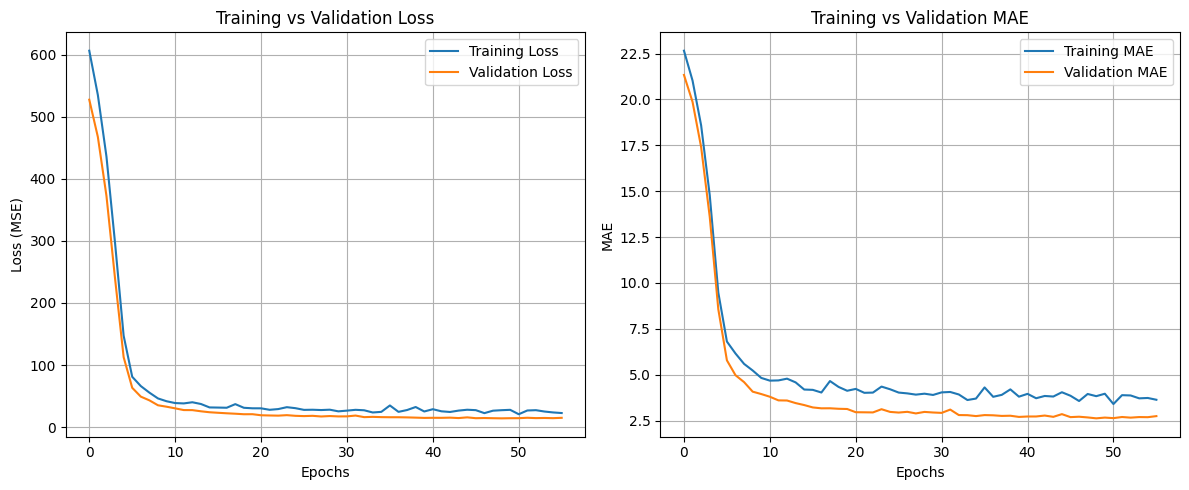

In [24]:
# Import the 'pyplot' module from matplotlib as 'plt' to enable creating 2D static plots and charts. This is important for visualizing the training progression of the neural network over different epochs.
import matplotlib.pyplot as plt

# -----------------------------
# Plot Training & Validation Loss
# -----------------------------
# Create a new plotting figure window with a width of 12 inches and a height of 5 inches. This is important to provide ample space for two side-by-side subplot visualizations.
plt.figure(figsize=(12,5))

# Create the first subplot in a 1-row, 2-column grid. This is important because it arranges the loss plot on the left side, leaving the right side open for the metric plot.
plt.subplot(1,2,1)
# Plot the training loss (MSE) history over epochs. This is important to verify that the training loss is steadily decreasing, indicating that the network is successfully learning.
plt.plot(history.history['loss'], label='Training Loss')
# Plot the validation loss (MSE) history over epochs. This is important to monitor for signs of overfitting (e.g., if validation loss starts to rise while training loss continues to fall).
plt.plot(history.history['val_loss'], label='Validation Loss')

# Set the title for the first subplot to describe what it visualizes. This is important for making the plot self-documenting and easy to interpret.
plt.title('Training vs Validation Loss')
# Set the label for the x-axis to 'Epochs'. This is important to denote the training progress step dimension.
plt.xlabel('Epochs')
# Set the label for the y-axis to 'Loss (MSE)'. This is important to specify the loss unit (Mean Squared Error) being monitored.
plt.ylabel('Loss (MSE)')
# Render the legend containing the labels defined in the plot calls. This is important to clearly distinguish between the training and validation lines.
plt.legend()
# Turn on the grid lines for the first subplot. This is important to make it easier to read exact numeric values off the loss curve.
plt.grid(True)

# -----------------------------
# Plot Training & Validation MAE
# -----------------------------
# Create the second subplot in a 1-row, 2-column grid. This is important because it places the MAE metric plot on the right side of the figure.
plt.subplot(1,2,2)

# Plot the training Mean Absolute Error (MAE) history over epochs. This is important to track the evolution of absolute prediction errors on the training dataset.
plt.plot(history.history['mae'], label='Training MAE')
# Plot the validation Mean Absolute Error (MAE) history over epochs. This is important to observe the model's accuracy on the validation subset throughout the training phase.
plt.plot(history.history['val_mae'], label='Validation MAE')

# Set the title for the second subplot to indicate its contents. This is important for clear chart identification.
plt.title('Training vs Validation MAE')
# Set the label for the x-axis to 'Epochs' for consistency and clarity. This is important to represent training cycles.
plt.xlabel('Epochs')
# Set the label for the y-axis to 'MAE' (Mean Absolute Error). This is important to specify the absolute price error scale in $1000s.
plt.ylabel('MAE')
# Display the legend for the second subplot. This is important to let the viewer easily distinguish training MAE from validation MAE.
plt.legend()
# Enable the grid lines for the second subplot. This is important to help read the specific MAE values on the chart visually.
plt.grid(True)

# Adjust the subplots' layout dynamically to prevent overlaps between text labels and plots. This is important for clean, publication-ready figure exports.
plt.tight_layout()
# Render the final figure window displaying both subplots on the screen. This is important to output the visualization to the user interface.
plt.show()

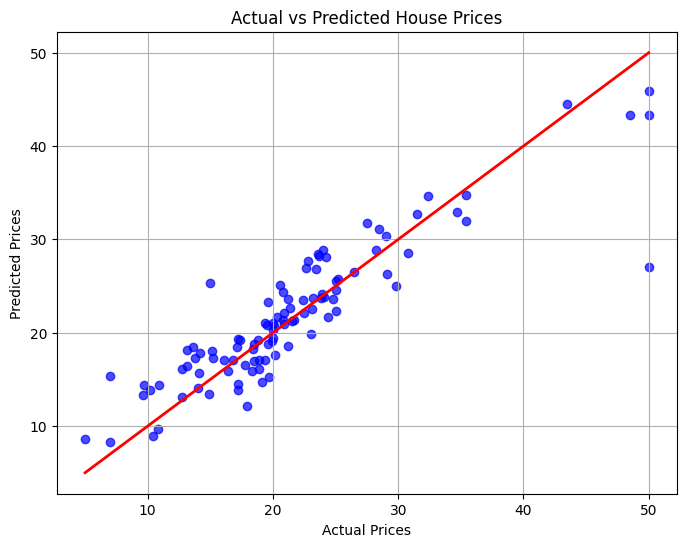

In [25]:
# -----------------------------
# Scatter Plot: Actual vs Predicted
# -----------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.grid(True)
plt.show()